
# Projekt: Dyfuzja ciepła w pręcie — numeryczne modelowanie jednorodne i niejednorodne

**Temat:** Numeryczna symulacja przepływu ciepła w pręcie oraz analiza wpływu zmiennych parametrów materiałowych (niejednorodności) na rozkład temperatury.

Pomysł jest prosty i ma bezpośrednie przełożenie inżynierskie: badamy jednowymiarowy pręt, którego końce utrzymywane są w stałych, skrajnych temperaturach (np. 100°C z jednej strony i 0°C z drugiej), a wewnątrz nakładamy narzucony profil początkowy. Pręt może być lity (jednorodny, np. wykonany w całości ze stali) lub złożony z różnych metali (niejednorodny, np. zespawane ze sobą odcinki stali i miedzi). Chcemy policzyć, jak temperatura rozkłada się i ewoluuje w czasie wewnątrz pręta, w sytuacjach, gdzie klasyczna matematyka analityczna przestaje wystarczać.

Notebook pokazuje:

* **Model fizyczny i założenia** dla przewodnictwa cieplnego (równania w postaci różniczkowej i konserwatywnej).
* **Jawną metodę Eulera** przetestowaną na materiale jednorodnym.
* **Warunek stabilności Couranta-Friedrichsa-Lewy'ego (CFL)** i jaskrawy przykład tego, co idzie źle (eksplozja numeryczna), gdy go złamiemy.
* **Bezwarunkowo stabilną metodę Cranka–Nicolsona** opartą na rozwiązywaniu układów równań liniowych z macierzami rzadkimi.
* **Symulację pręta niejednorodnego** z wykorzystaniem średniej harmonicznej na styku różnych materiałów (stal vs miedź).
* **Podejście spektralne (FFT)** w dziedzinie częstotliwości jako wysoce precyzyjny punkt odniesienia.
* **Zestawienie algorytmów numerycznych** i ich złożoności obliczeniowej (od $\mathcal{O}(N)$ do $\mathcal{O}(N \log N)$).
* **Czystą, wektorową implementację** algorytmów w języku Julia z wykorzystaniem pakietów `LinearAlgebra`, `SparseArrays` oraz `FFTW`.

## 1. Model matematyczny

Dla jednowymiarowego pręta rozważamy ogólne równanie przewodnictwa ciepła, które pozwala uwzględnić właściwości materiału zależne od położenia:

$$
\rho(x)c(x)\frac{\partial T}{\partial t}
=
\frac{\partial}{\partial x}\left(k(x)\frac{\partial T}{\partial x}\right),
$$

gdzie:

- $T(x,t)$ — temperatura w pręcie,
- $k(x)$ — przewodność cieplna materiału $[W/(mK)]$,
- $\rho(x)$ — gęstość $[kg/m^3]$,
- $c(x)$ — ciepło właściwe $[J/(kgK)]$.

W przypadku **pręta jednorodnego** (np. wykonanego w całości z jednego metalu), parametry te są stałe, a równanie redukuje się do klasycznej postaci:

$$
\frac{\partial T}{\partial t}=\alpha \frac{\partial^2 T}{\partial x^2},
\qquad
\alpha=\frac{k}{\rho c}.
$$

W projekcie przyjmujemy warunki brzegowe Dirichleta, wymuszając stałą temperaturę na końcach pręta:

$$
T(0,t)=T_{lewy}, \qquad T(L,t)=T_{prawy}.
$$

Interpretacja:

- lewy koniec pręta utrzymywany jest w zadanej temperaturze (np. ogrzewany do $100^\circ C$),
- prawy koniec pręta utrzymywany jest w zadanej temperaturze (np. chłodzony do $0^\circ C$).


## 2. Instalacja i import pakietów

Ten notebook używa głównie standardowych bibliotek Julii. Do wykresów używany jest `Plots.jl`.


In [19]:

using LinearAlgebra
using SparseArrays
using Printf
using LinearAlgebra
using SparseArrays

try
    using Plots
    using FFTW
catch
    import Pkg
    Pkg.add("Plots")
    Pkg.add("FFTW")
    using Plots
    using FFTW
end

default(size=(900, 520), linewidth=2, margin=5Plots.mm)


## 3. Dane materiałowe

Wartości poniżej są orientacyjne i służą do projektu numerycznego. Dla pracy końcowej można je zastąpić wartościami z norm, podręczników lub kart materiałowych producentów.


In [20]:
Base.@kwdef struct Segment
    name::String
    length::Float64      # m (zamiast grubości ściany)
    k::Float64           # W/(m K) - przewodność cieplna
    rho::Float64         # kg/m^3 - gęstość
    c::Float64           # J/(kg K) - ciepło właściwe
end

function print_segments(segments)
    println("Struktura pręta:")
    for s in segments
        @printf("%-15s długość = %.3f m, k = %6.2f W/(mK), rho*c = %.2e J/(m³K)\n",
                s.name, s.length, s.k, s.rho*s.c)
    end
    
    # Opór cieplny (zastępczy, zakłada pole przekroju 1 m^2)
    R = sum(s.length / s.k for s in segments)
    @printf("\nCałkowity opór cieplny R = %.5f m²K/W\n", R)
end

rod_homogeneous = [
    Segment(name="Stal", length=1.0, k=50.0, rho=7800.0, c=450.0)
]

rod_heterogeneous = [
    Segment(name="Stal",  length=0.5, k=50.0,  rho=7800.0, c=450.0),
    Segment(name="Miedź", length=0.5, k=400.0, rho=8900.0, c=390.0)
]

print_segments(rod_heterogeneous)


Struktura pręta:
Stal            długość = 0.500 m, k =  50.00 W/(mK), rho*c = 3.51e+06 J/(m³K)
Miedź           długość = 0.500 m, k = 400.00 W/(mK), rho*c = 3.47e+06 J/(m³K)

Całkowity opór cieplny R = 0.01125 m²K/W



## 4. Budowa siatki obliczeniowej

Dzielimy pręt na $N_x$ punktów. Każdemu punktowi przypisujemy materiał, czyli wartości $k$ oraz $\rho c$.

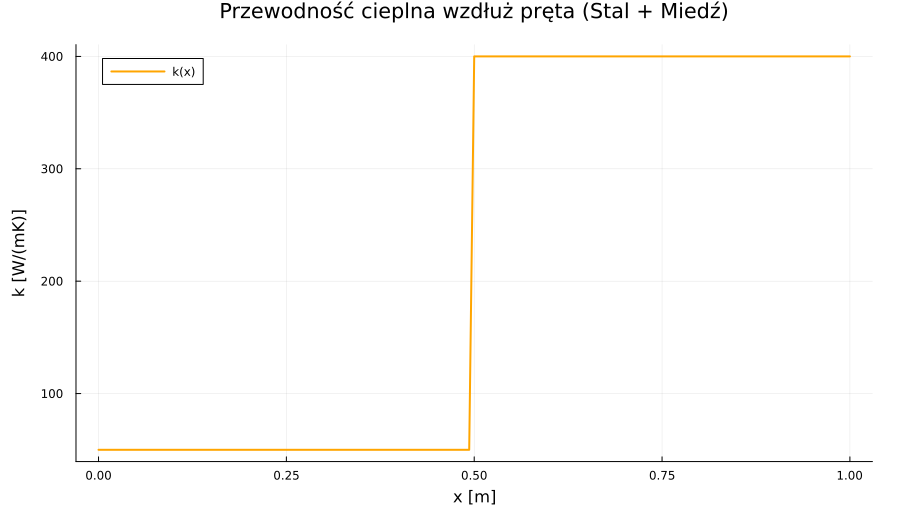

In [21]:
function build_rod(segments::Vector{Segment}; Nx::Int=151)
    L = sum(s.length for s in segments)
    x = collect(range(0.0, L; length=Nx))
    edges = cumsum([s.length for s in segments])

    k = zeros(Float64, Nx)
    rhoc = zeros(Float64, Nx)
    names = Vector{String}(undef, Nx)

    for (i, xi) in enumerate(x)
        # +eps pomaga poprawnie przypisać punkt x=0 do pierwszego segmentu
        j = searchsortedfirst(edges, xi + eps(Float64))
        j = clamp(j, 1, length(segments))
        segment = segments[j]
        k[i] = segment.k
        rhoc[i] = segment.rho * segment.c
        names[i] = segment.name
    end

    return x, k, rhoc, names
end

x, k, rhoc, names = build_rod(rod_heterogeneous; Nx=151)

plot(x, k,
     xlabel="x [m]",
     ylabel="k [W/(mK)]",
     title="Przewodność cieplna wzdłuż pręta (Stal + Miedź)",
     label="k(x)",
     color=:orange)

## 5. Dyskretyzacja operatora przewodzenia

Dla pręta o właściwościach zmiennych w przestrzeni (niejednorodnego) najwygodniejsza jest postać konserwatywna:

$$\rho_i c_i \frac{dT_i}{dt}=\frac{1}{\Delta x^2}\left[k_{i+1/2}(T_{i+1}-T_i)-k_{i-1/2}(T_i-T_{i-1})\right]$$

Na granicach między różnymi materiałami pręta (np. na spawie stali z miedzią) używamy średniej harmonicznej:

$$k_{i+1/2}=\frac{2k_i k_{i+1}}{k_i+k_{i+1}}$$

Jest to znacznie sensowniejsze w inżynierii niż zwykła średnia arytmetyczna, ponieważ na styku dwóch metali głównym dławikiem dla przepływu ciepła staje się segment o mniejszej przewodności.

In [22]:
harmonic_mean(a, b) = 2a*b/(a+b)

# Obliczanie przewodności na styku komórek (np. na spawie stali z miedzią)
function face_conductivity(k)
    return [harmonic_mean(k[i], k[i+1]) for i in 1:length(k)-1]
end

# Budowa rzadkiej macierzy trójprzekątniowej dla pręta niejednorodnego
function build_operator(k, rhoc, dx)
    N = length(k)
    n = N - 2                       # liczba punktów wewnętrznych pręta (bez brzegów)
    kh = face_conductivity(k)

    rows = Int[]
    cols = Int[]
    vals = Float64[]

    leftcoef = zeros(Float64, n)    # wpływ lewego końca pręta (np. 100°C)
    rightcoef = zeros(Float64, n)   # wpływ prawego końca pręta (np. 0°C)

    for j in 1:n
        i = j + 1                   # indeks globalny wzdłuż pręta
        aL = kh[i-1] / (rhoc[i] * dx^2)
        aR = kh[i]   / (rhoc[i] * dx^2)

        # Główna przekątna
        push!(rows, j); push!(cols, j); push!(vals, -(aL + aR))

        # Lewy sąsiad lub lewy brzeg
        if j > 1
            push!(rows, j); push!(cols, j-1); push!(vals, aL)
        else
            leftcoef[j] = aL
        end

        # Prawy sąsiad lub prawy brzeg
        if j < n
            push!(rows, j); push!(cols, j+1); push!(vals, aR)
        else
            rightcoef[j] = aR
        end
    end

    # Utworzenie macierzy rzadkiej w celu optymalizacji pamięci i czasu
    L_matrix = sparse(rows, cols, vals, n, n)
    return L_matrix, leftcoef, rightcoef
end


# --- Weryfikacja działania funkcji na naszej siatce pręta ---
dx = x[2] - x[1]
Lop, leftcoef, rightcoef = build_operator(k, rhoc, dx)

println("Zbudowano macierz rzadką (Sparse Matrix) o rozmiarze: ", size(Lop))


Zbudowano macierz rzadką (Sparse Matrix) o rozmiarze: (149, 149)



## 6. Metody numeryczne

### 6.1 Jawna metoda Eulera

Schemat:

$$
T^{n+1}=T^n+\Delta t\,L T^n.
$$

Zaleta: bardzo prosty i tani krok czasowy.

Wada: metoda jest stabilna tylko dla odpowiednio małego kroku czasu.

### 6.2 Niejawna metoda Eulera

Schemat:

$$
(I-\Delta t L)T^{n+1}=T^n.
$$

Zaleta: stabilna dla dużych kroków czasu.

Wada: w każdym kroku rozwiązujemy układ równań liniowych.

### 6.3 Crank–Nicolson

Schemat:

$$
(I-\frac{\Delta t}{2}L)T^{n+1}=(I+\frac{\Delta t}{2}L)T^n.
$$

Zaleta: dokładniejszy w czasie niż obie metody Eulera.


In [23]:
harmonic_mean(a, b) = 2a*b/(a+b)

function face_conductivity(k)
    return [harmonic_mean(k[i], k[i+1]) for i in 1:length(k)-1]
end

function build_operator(k, rhoc, dx)
    N = length(k)
    n = N - 2
    kh = face_conductivity(k)

    rows, cols, vals = Int[], Int[], Float64[]
    leftcoef, rightcoef = zeros(n), zeros(n)

    for j in 1:n
        i = j + 1
        aL = kh[i-1] / (rhoc[i] * dx^2)
        aR = kh[i]   / (rhoc[i] * dx^2)

        push!(rows, j); push!(cols, j); push!(vals, -(aL + aR))
        if j > 1 push!(rows, j); push!(cols, j-1); push!(vals, aL) else leftcoef[j] = aL end
        if j < n push!(rows, j); push!(cols, j+1); push!(vals, aR) else rightcoef[j] = aR end
    end
    return sparse(rows, cols, vals, n, n), leftcoef, rightcoef
end

function explicit_dt_limit(k, rhoc, dx; safety=0.8)
    kh = face_conductivity(k)
    rates = [(kh[i-1] + kh[i]) / (rhoc[i] * dx^2) for i in 2:length(k)-1]
    return safety / maximum(rates)
end

function solve_rod_theta(x, k, rhoc; T_initial, T_left, T_right, dt, t_end, theta, save_every=1)
    dx = x[2] - x[1]
    Lop, leftcoef, rightcoef = build_operator(k, rhoc, dx)
    Id = spdiagm(0 => ones(length(x)-2))

    A = Id - theta * dt * Lop
    B = Id + (1 - theta) * dt * Lop
    F = factorize(A)

    T = copy(T_initial)
    
    get_T_left(t)  = T_left isa Function ? T_left(t) : T_left
    get_T_right(t) = T_right isa Function ? T_right(t) : T_right
    
    T[1] = get_T_left(0.0)
    T[end] = get_T_right(0.0)
    
    nt = ceil(Int, t_end/dt)
    times = Float64[]
    saved = Vector{Vector{Float64}}()

    for n in 0:nt
        t = n * dt
        if n % save_every == 0
            push!(times, t)
            push!(saved, copy(T))
        end
        n == nt && break
        
        b_now = leftcoef .* get_T_left(t) .+ rightcoef .* get_T_right(t)
        b_next = leftcoef .* get_T_left(t + dt) .+ rightcoef .* get_T_right(t + dt)
        
        rhs = B * T[2:end-1] .+ dt .* ((1 - theta) .* b_now .+ theta .* b_next)
        T[2:end-1] .= F \ rhs
        T[1] = get_T_left(t + dt)
        T[end] = get_T_right(t + dt)
    end
    
    return times, permutedims(hcat(saved...))
end

solve_rod_explicit(args...; kwargs...) = solve_rod_theta(args...; theta=0.0, kwargs...)
solve_rod_crank_nicolson(args...; kwargs...) = solve_rod_theta(args...; theta=0.5, kwargs...)
solve_rod_implicit(args...; kwargs...) = solve_rod_theta(args...; theta=1.0, kwargs...)

solve_rod_implicit (generic function with 1 method)

### SYMULACJA — EULER JAWNY

In [24]:
x, k_het, rhoc_het = build_rod(rod_heterogeneous; Nx=151)

T0_het = 200 .* exp.(-((x .- 0.5).^2) ./ (2 * 0.06^2))

dx = x[2] - x[1]

dt_explicit = explicit_dt_limit(k_het, rhoc_het, dx; safety=0.45)

println("Bezpieczny krok czasowy dla jawnego Eulera:")
println("dt = ", dt_explicit, " s")

Bezpieczny krok czasowy dla jawnego Eulera:
dt = 0.08677500000000003 s


┌ Info: Saved animation to c:\Users\jakub\Desktop\pret_stal_miedz_euler_jawny.gif
└ @ Plots C:\Users\jakub\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\jakub\\Desktop\\pret_stal_miedz_euler_jawny.gif")
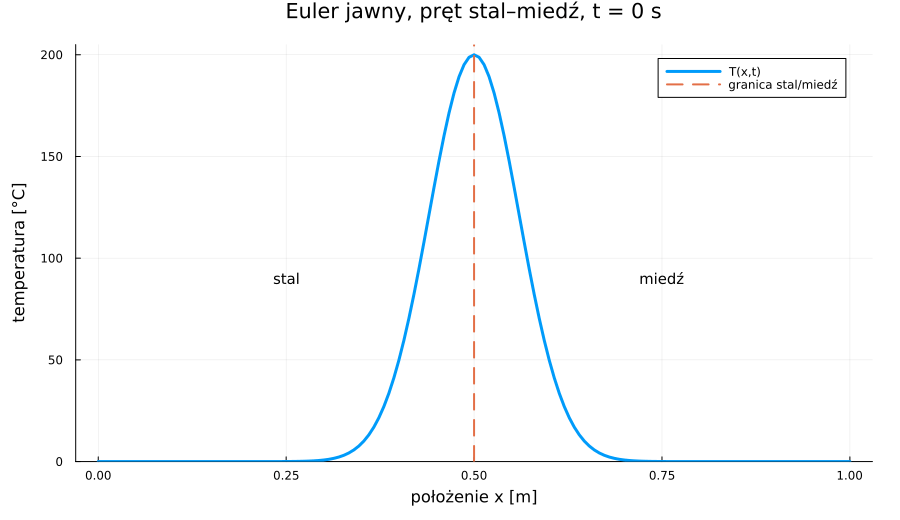

In [25]:
t_end = 2000.0

save_every = max(1, ceil(Int, 20.0 / dt_explicit))

times_fe, sol_fe = solve_rod_explicit(
    x, k_het, rhoc_het;
    T_initial = T0_het,
    T_left  = t -> 0.0,
    T_right = t -> 0.0,
    dt = dt_explicit,
    t_end = t_end,
    save_every = save_every
)

anim = @animate for idx in 1:length(times_fe)
    plot(
        x,
        sol_fe[idx, :],
        linewidth = 3,
        label = "T(x,t)",
        xlabel = "położenie x [m]",
        ylabel = "temperatura [°C]",
        title = "Euler jawny, pręt stal–miedź, t = $(round(Int, times_fe[idx])) s",
        ylim = (0, 205),
        legend = :topright
    )

    vline!(
        [0.5],
        linestyle = :dash,
        linewidth = 2,
        label = "granica stal/miedź"
    )

    annotate!(0.25, 90, text("stal", 10))
    annotate!(0.75, 90, text("miedź", 10))
end

gif(anim, "pret_stal_miedz_euler_jawny.gif", fps = 5)

## SYMULACJE

┌ Info: Saved animation to c:\Users\jakub\Desktop\pret_stal_miedz_temperatura.gif
└ @ Plots C:\Users\jakub\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\jakub\\Desktop\\pret_stal_miedz_temperatura.gif")
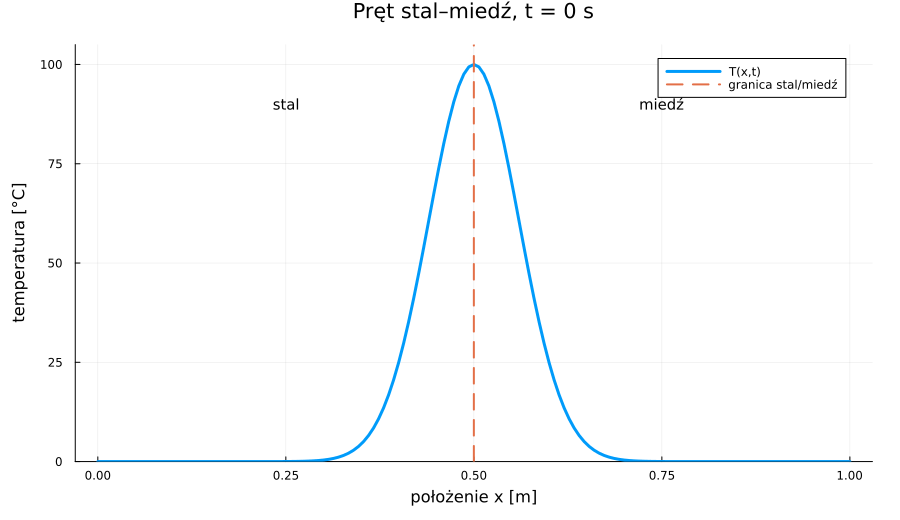

In [26]:
# Symulacja: temperatura początkowo skupiona w środku pręta
x, k_het, rhoc_het = build_rod(rod_heterogeneous; Nx=151)

T0_het = 100 .* exp.(-((x .- 0.5).^2) ./ (2 * 0.06^2))

dt = 100.0
t_end = 2000.0

times_be, sol_be = solve_rod_implicit(
    x, k_het, rhoc_het;
    T_initial = T0_het,
    T_left  = t -> 0.0,
    T_right = t -> 0.0,
    dt = dt,
    t_end = t_end,
    save_every = 1
)

anim = @animate for idx in 1:length(times_be)
    plot(
        x,
        sol_be[idx, :],
        linewidth = 3,
        label = "T(x,t)",
        xlabel = "położenie x [m]",
        ylabel = "temperatura [°C]",
        title = "Pręt stal–miedź, t = $(round(Int, times_be[idx])) s",
        ylim = (0, 105),
        legend = :topright
    )

    vline!(
        [0.5],
        linestyle = :dash,
        linewidth = 2,
        label = "granica stal/miedź"
    )

    annotate!(0.25, 90, text("stal", 10))
    annotate!(0.75, 90, text("miedź", 10))
end

gif(anim, "pret_stal_miedz_temperatura.gif", fps = 5)

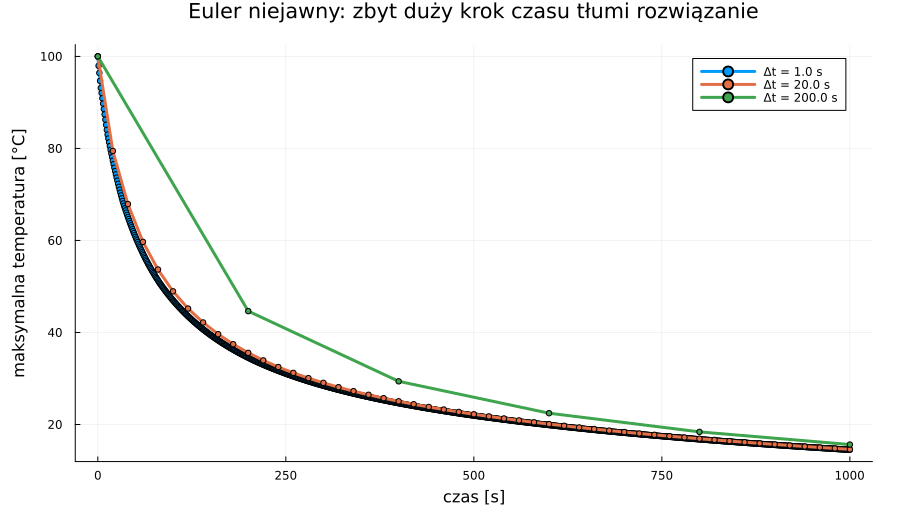

In [27]:
# Ten sam warunek początkowy dla wszystkich testów
T0_test = 100 .* exp.(-((x .- 0.5).^2) ./ (2 * 0.05^2))

dt_values = [1.0, 20.0, 200.0]
t_end = 1000.0

p = plot(
    xlabel = "czas [s]",
    ylabel = "maksymalna temperatura [°C]",
    title = "Euler niejawny: zbyt duży krok czasu tłumi rozwiązanie",
    legend = :topright
)

for dt in dt_values
    times, sol = solve_rod_implicit(
        x, k_het, rhoc_het;
        T_initial = T0_test,
        T_left  = t -> 0.0,
        T_right = t -> 0.0,
        dt = dt,
        t_end = t_end,
        save_every = 1
    )

    Tmax = [maximum(sol[i, :]) for i in 1:size(sol, 1)]

    plot!(
        p,
        times,
        Tmax,
        linewidth = 3,
        marker = :circle,
        markersize = 3,
        label = "Δt = $(dt) s"
    )
end

display(p)

### SYMULACJE CRANK NICOLSON

In [28]:
N = 100 
L = sum(s.length for s in rod_heterogeneous) #calkowita długość pręta
x = collect(range(0, L, length=N))

#Pułapka: niejednorodność
k_rod = zeros(N)
rhoc_rod = zeros(N)

for i in 1:N
    #lewa - stal, prawa miedz
    if x[i] <= rod_heterogeneous[1].length
        k_rod[i] = rod_heterogeneous[1].k
        rhoc_rod[i] = rod_heterogeneous[1].rho * rod_heterogeneous[1].c
    else
        k_rod[i] = rod_heterogeneous[2].k
        rhoc_rod[i] = rod_heterogeneous[2].rho * rod_heterogeneous[2].c
    end
end

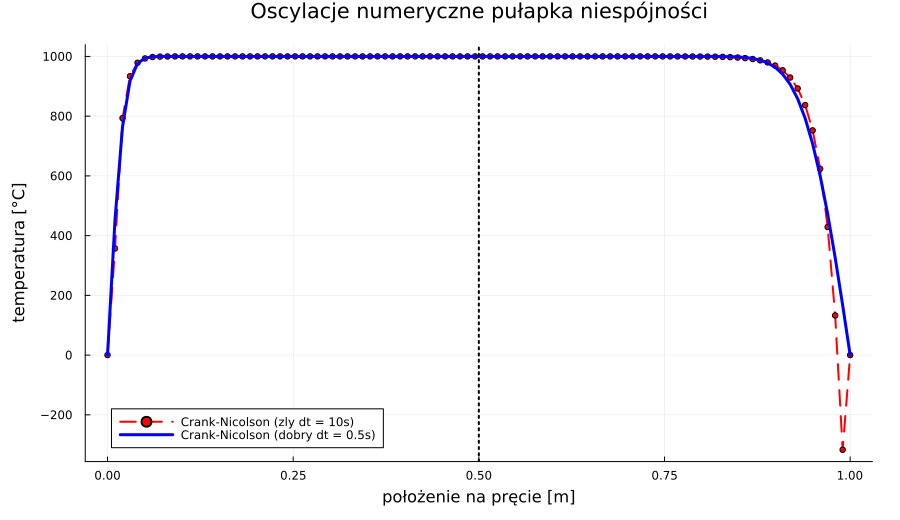

In [29]:
#PUŁAPKA: Niespójność warunków brzegowych
#rozgrzewamy pręt do 1000°C i natychmiastowo stykamy brzegi z termostatem 0°C.

T_initial = fill(1000.0, N)
T_initial[1] = 0.0   # Gwałtowny skok (brzeg lewy)
T_initial[end] = 0.0 # Gwałtowny skok (brzeg prawy)

t_end_exp = 200.0 # Całkowity czas symulacji (s)

# Funkcja pomocnicza potrzebna do nowego solvera z grupy (jeśli nie jest zdefiniowana wyżej)
if !@isdefined(boundary_vector)
    boundary_vector(leftcoef, rightcoef, TL, TR) = leftcoef .* TL .+ rightcoef .* TR
end

#EKSPERYMENT 1: Zbyt duży krok czasowy -> Oscylacje numeryczne
dt_bad = 10.0 #sek
times_bad, results_bad = solve_rod_crank_nicolson(x, k_rod, rhoc_rod, 
                                                   T_initial=T_initial, 
                                                   T_left = t -> 0.0, T_right = t -> 0.0, 
                                                   dt=dt_bad, t_end=t_end_exp)

#EKSPERYMENT 2: Poprawnie dobrany krok czasowy
dt_good = 0.5 #sek
times_good, results_good = solve_rod_crank_nicolson(x, k_rod, rhoc_rod, 
                                                     T_initial=T_initial, 
                                                     T_left = t -> 0.0, T_right = t -> 0.0, 
                                                     dt=dt_good, t_end=t_end_exp, save_every=4)


idx_bad = argmin(abs.(times_bad .- 10.0))
idx_good = argmin(abs.(times_good .- 10.0))

p1 = plot(x, results_bad[idx_bad, :], label="Crank-Nicolson (zly dt = 10s)", 
          title="Oscylacje numeryczne pułapka niespójności",
          xlabel="położenie na pręcie [m]", ylabel="temperatura [°C]",
          color=:red, linestyle=:dash, marker=:circle, markersize=3)

plot!(p1, x, results_good[idx_good, :], label="Crank-Nicolson (dobry dt = 0.5s)", color=:blue, linewidth=3)
vline!(p1, [0.5], label = "", color=:black, linestyle=:dot)
display(p1)

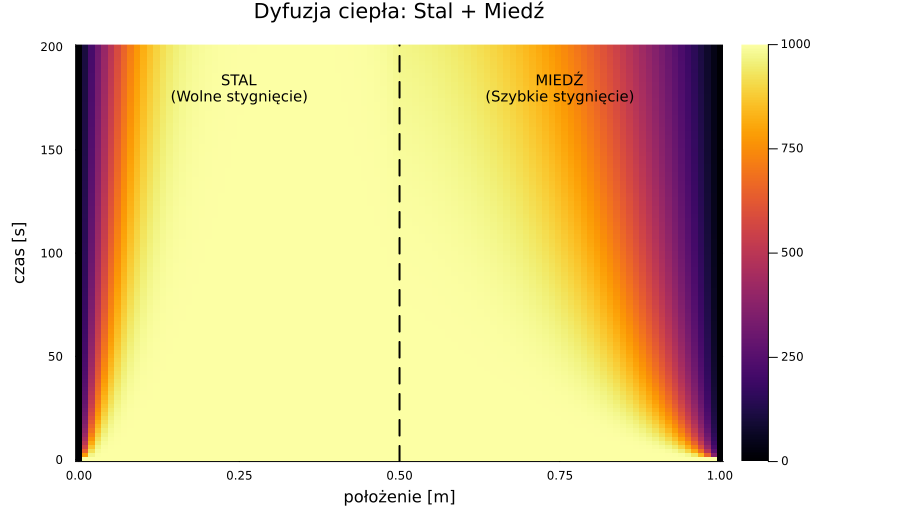

In [30]:
#Heatmapa asymetrycznego przepływu ciepła
p2 = heatmap(x, times_good, results_good, 
             title="Dyfuzja ciepła: Stal + Miedź", 
             xlabel="położenie [m]", ylabel="czas [s]", 
             color=:inferno, right_margin=20Plots.mm)

vline!(p2, [0.5], label="", color=:black, linestyle=:dash, linewidth=2)
annotate!(p2, 0.25, t_end_exp * 0.9, text("STAL\n(Wolne stygnięcie)", :black, 10, :center))
annotate!(p2, 0.75, t_end_exp * 0.9, text("MIEDŹ\n(Szybkie stygnięcie)", :black, 10, :center))
display(p2)

In [31]:
#Animacja stygnięcia pręta niejednorodnego
frames_to_render = 1:1:size(results_good, 1)

anim = @animate for i in frames_to_render
    current_time = times_good[i]

    p_anim = plot(x, results_good[i, :], 
                  title = @sprintf("Metoda Crank-Nicolson\nczas: %.1f s", current_time),
                  xlabel = "położenie na pręcie [m]", 
                  ylabel = "temperatura [°C]",
                  label = "rozkład temperatury T(x)",
                  color = :firebrick, 
                  linewidth = 4,
                  ylim = (-50, 1050),
                  legend = :bottomleft)

    vline!(p_anim, [0.5], label="granica stal/miedź", color=:black, linestyle=:dash, linewidth=2)
    annotate!(p_anim, 0.25, 950, text("STAL", :black, 12))
    annotate!(p_anim, 0.75, 950, text("MIEDŹ", :black, 12))
end

gif_filename = "crank_nicolson_cooling.gif"
gif(anim, gif_filename, fps = 15)
println("Animacja zapisana: ", gif_filename)

Animacja zapisana: crank_nicolson_cooling.gif


┌ Info: Saved animation to c:\Users\jakub\Desktop\crank_nicolson_cooling.gif
└ @ Plots C:\Users\jakub\.julia\packages\Plots\GIume\src\animation.jl:156


## 7. Analiza dokładności i wydajności

Porównujemy trzy schematy czasowe:
- metodę Eulera jawną,
- metodę Eulera niejawną,
- metodę Cranka–Nicolsona.

Dokładność oceniamy względem rozwiązania referencyjnego.
Wydajność oceniamy przez czas wykonania obliczeń i liczbę kroków czasowych.

In [32]:
x, k_het, rhoc_het, _ = build_rod(rod_heterogeneous; Nx=151)
dx = x[2] - x[1]
T0 = 100 .* exp.(-((x .- 0.5).^2) ./ (2 * 0.05^2))

function final_temperature(solver, x, k, rhoc; T_initial, T_left, T_right, dt, t_end)
    nsteps = ceil(Int, t_end / dt)
    _, sol = solver(
        x, k, rhoc;
        T_initial = T_initial,
        T_left = T_left,
        T_right = T_right,
        dt = dt,
        t_end = t_end,
        save_every = nsteps
    )
    return sol[end, :]
end

function error_norms(T, Tref, dx)
    err = T .- Tref
    L2 = sqrt(sum(abs2, err) * dx)
    Linf = maximum(abs.(err))
    return L2, Linf
end

t_acc = 100.0

dt_ref = 0.05
T_ref = final_temperature(
    solve_rod_crank_nicolson, x, k_het, rhoc_het;
    T_initial = T0, T_left = 0.0, T_right = 0.0,
    dt = dt_ref, t_end = t_acc
)

dt_exp = explicit_dt_limit(k_het, rhoc_het, dx; safety=0.9)
dt_imp = 10.0
dt_cn  = 10.0

T_exp = final_temperature(
    solve_rod_explicit, x, k_het, rhoc_het;
    T_initial = T0, T_left = 0.0, T_right = 0.0,
    dt = dt_exp, t_end = t_acc
)

T_imp = final_temperature(
    solve_rod_implicit, x, k_het, rhoc_het;
    T_initial = T0, T_left = 0.0, T_right = 0.0,
    dt = dt_imp, t_end = t_acc
)

T_cn = final_temperature(
    solve_rod_crank_nicolson, x, k_het, rhoc_het;
    T_initial = T0, T_left = 0.0, T_right = 0.0,
    dt = dt_cn, t_end = t_acc
)

# błędy
L2_exp, Linf_exp = error_norms(T_exp, T_ref, dx)
L2_imp, Linf_imp = error_norms(T_imp, T_ref, dx)
L2_cn,  Linf_cn  = error_norms(T_cn,  T_ref, dx)

println("Porównanie dokładności względem rozwiązania referencyjnego")
@printf("%-18s %-12s %-15s %-15s\n", "Metoda", "dt [s]", "błąd L2", "błąd L∞")
println("-"^65)
@printf("%-18s %-12.5f %-15.6e %-15.6e\n", "Euler jawny", dt_exp, L2_exp, Linf_exp)
@printf("%-18s %-12.5f %-15.6e %-15.6e\n", "Euler niejawny", dt_imp, L2_imp, Linf_imp)
@printf("%-18s %-12.5f %-15.6e %-15.6e\n", "Crank-Nicolson", dt_cn, L2_cn, Linf_cn)

Porównanie dokładności względem rozwiązania referencyjnego
Metoda             dt [s]       błąd L2         błąd L∞        
-----------------------------------------------------------------
Euler jawny        0.17355      1.558763e-02    4.711885e-02   
Euler niejawny     10.00000     3.862792e-01    1.170538e+00   
Crank-Nicolson     10.00000     1.504369e-02    7.566322e-02   


### Wydajność obliczeń

Porównujemy czas wykonania długiej symulacji dla każdej metody.
Na etykietach wykresu podano również zastosowany krok czasu i liczbę kroków czasowych.

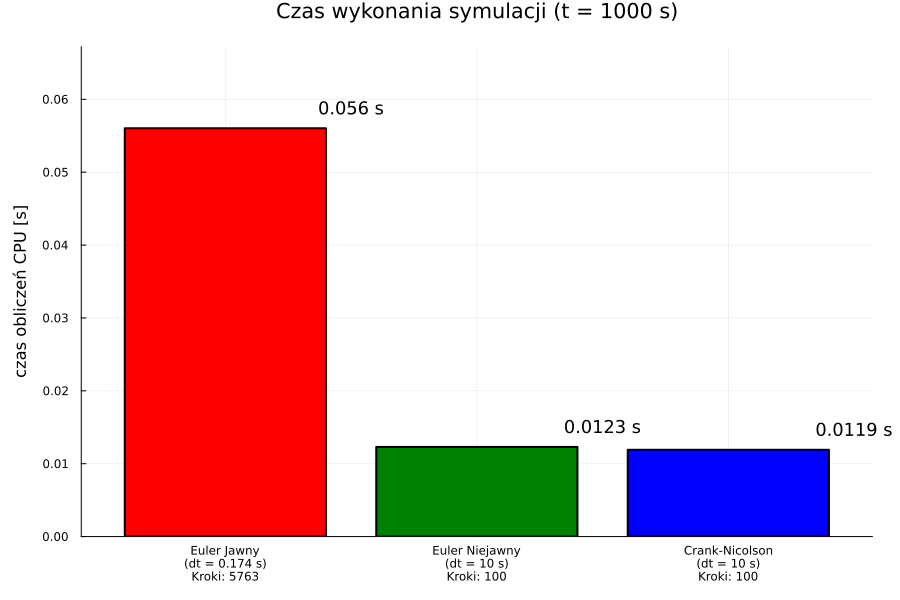

Porównanie wydajności
Metoda             dt [s]       kroki        czas [s]    
------------------------------------------------------------
Euler jawny        0.17355      5763         0.056026    
Euler niejawny     10.00000     100          0.012299    
Crank-Nicolson     10.00000     100          0.011912    


"c:\\Users\\jakub\\Desktop\\porownanie_wydajnosci.png"

In [33]:
x, k_het, rhoc_het, _ = build_rod(rod_heterogeneous; Nx=151)
dx = x[2] - x[1]
T0 = 100 .* exp.(-((x .- 0.5).^2) ./ (2 * 0.05^2))

dt_safe = explicit_dt_limit(k_het, rhoc_het, dx; safety=0.9)
t_dlugie = 1000.0

solve_rod_explicit(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=dt_safe, t_end=1.0)
solve_rod_implicit(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=10.0, t_end=1.0)
solve_rod_crank_nicolson(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=10.0, t_end=1.0)

czas_exp = @elapsed solve_rod_explicit(
    x, k_het, rhoc_het;
    T_initial=T0, T_left=0.0, T_right=0.0,
    dt=dt_safe, t_end=t_dlugie, save_every=100
)

czas_imp = @elapsed solve_rod_implicit(
    x, k_het, rhoc_het;
    T_initial=T0, T_left=0.0, T_right=0.0,
    dt=10.0, t_end=t_dlugie, save_every=1
)

czas_cn = @elapsed solve_rod_crank_nicolson(
    x, k_het, rhoc_het;
    T_initial=T0, T_left=0.0, T_right=0.0,
    dt=10.0, t_end=t_dlugie, save_every=1
)

kroki_exp = ceil(Int, t_dlugie / dt_safe)
kroki_imp = ceil(Int, t_dlugie / 10.0)
kroki_cn  = ceil(Int, t_dlugie / 10.0)

println("Porównanie wydajności")
@printf("%-18s %-12s %-12s %-12s\n", "Metoda", "dt [s]", "kroki", "czas [s]")
println("-"^60)
@printf("%-18s %-12.5f %-12d %-12.6f\n", "Euler jawny", dt_safe, kroki_exp, czas_exp)
@printf("%-18s %-12.5f %-12d %-12.6f\n", "Euler niejawny", 10.0, kroki_imp, czas_imp)
@printf("%-18s %-12.5f %-12d %-12.6f\n", "Crank-Nicolson", 10.0, kroki_cn, czas_cn)

metody = [
    "Euler Jawny\n(dt = $(round(dt_safe, digits=3)) s)\nKroki: $kroki_exp",
    "Euler Niejawny\n(dt = 10 s)\nKroki: $kroki_imp",
    "Crank-Nicolson\n(dt = 10 s)\nKroki: $kroki_cn"
]

czasy = [czas_exp, czas_imp, czas_cn]

max_y = maximum(czasy) * 1.2

p3 = bar(
    metody, czasy,
    title = "Czas wykonania symulacji (t = 1000 s)",
    ylabel = "czas obliczeń CPU [s]",
    color = [:red, :green, :blue],
    legend = false,
    size = (900, 600),
    ylim = (0, max_y)
)

for (i, czas) in enumerate(czasy)
    annotate!(p3, i, czas + maximum(czasy) * 0.05, text("$(round(czas, digits=4)) s", 12))
end

display(p3)
savefig(p3, "porownanie_wydajnosci.png")

## 8. Omówienie praktycznego znaczenia trzech metod

### 8.1 Euler jawny

Euler jawny ma znaczenie praktyczne przede wszystkim jako metoda szybka, prosta i bardzo przejrzysta. Jeden krok korzysta tylko z aktualnych temperatur w sąsiednich punktach, dlatego łatwo kontrolować przepływ informacji w siatce i łatwo wykrywać błędy implementacyjne. W projekcie jest szczególnie użyteczny do pokazania, dlaczego warunek CFL jest ważny: po jego przekroczeniu rozwiązanie przestaje mieć sens fizyczny, pojawiają się oscylacje, a temperatura może przyjmować wartości nierealistyczne.

W zastosowaniach inżynierskich metoda jawna nadaje się do krótkich symulacji, małych siatek albo sytuacji, w których i tak potrzebujemy bardzo małego kroku czasu, aby uchwycić szybkie zjawiska. Nie jest najlepszym wyborem dla długiego chłodzenia pręta lub bardzo gęstej siatki, bo liczba kroków staje się zbyt duża.

### 8.2 Euler niejawny

Euler niejawny jest praktycznie ważny, ponieważ pozwala stabilnie liczyć procesy dyfuzji nawet dla dużych kroków czasowych. W problemach przewodzenia ciepła bywa to bardzo korzystne, gdy interesuje nas długoterminowy trend: na przykład czas dochodzenia układu do stanu bliskiego ustalonemu albo ogólny kierunek zanikania temperatury.

Cena za stabilność to tłumienie numeryczne. Profil temperatury może zostać wygładzony szybciej niż w rzeczywistym procesie. Dlatego Euler niejawny jest dobry, gdy ważniejsza jest odporność i stabilność obliczeń niż bardzo dokładny opis krótkich stanów przejściowych. W naszym przykładzie pręta stal–miedź metoda dobrze pokazuje, że duży krok czasu nie powoduje wybuchu rozwiązania, ale może zaniżyć maksymalną temperaturę i spłaszczyć profil.

### 8.3 Crank–Nicolson

Crank–Nicolson jest najbardziej wartościowy praktycznie jako kompromis między stabilnością, kosztem i dokładnością. Ma drugi rząd dokładności w czasie, a koszt jednego kroku jest podobny do Eulera niejawnego, ponieważ korzysta z tego samego typu faktoryzacji macierzy rzadkiej. Dzięki temu nadaje się do analizy przebiegu przejściowego, np. do badania, jak szybko ciepło przechodzi ze stali do miedzi i jak asymetria materiałowa wpływa na rozkład temperatury.

Trzeba jednak pamiętać, że Crank–Nicolson nie zawsze jest automatycznie „najbezpieczniejszy”. Przy nagłych skokach temperatury, niespójnych warunkach początkowo-brzegowych albo zbyt dużym kroku czasu może generować oscylacje. W praktyce oznacza to konieczność kontroli kroku $\Delta t$, wygładzenia danych początkowych albo wykonania kilku pierwszych kroków bardziej tłumiącą metodą, np. Eulerem niejawnym.






| Metoda | Zastosowanie praktyczne | Ograniczenie |
|---|---|---|
| Euler jawny | Prosty schemat testowy i demonstracyjny | wymaga małego kroku czasu |
| Euler niejawny | Stabilne obliczenia dla długich symulacji | może silniej wygładzać rozwiązanie |
| Crank–Nicolson | Lepsza dokładność czasowa przy umiarkowanym koszcie | przy dużym kroku czasu może dawać oscylacje |


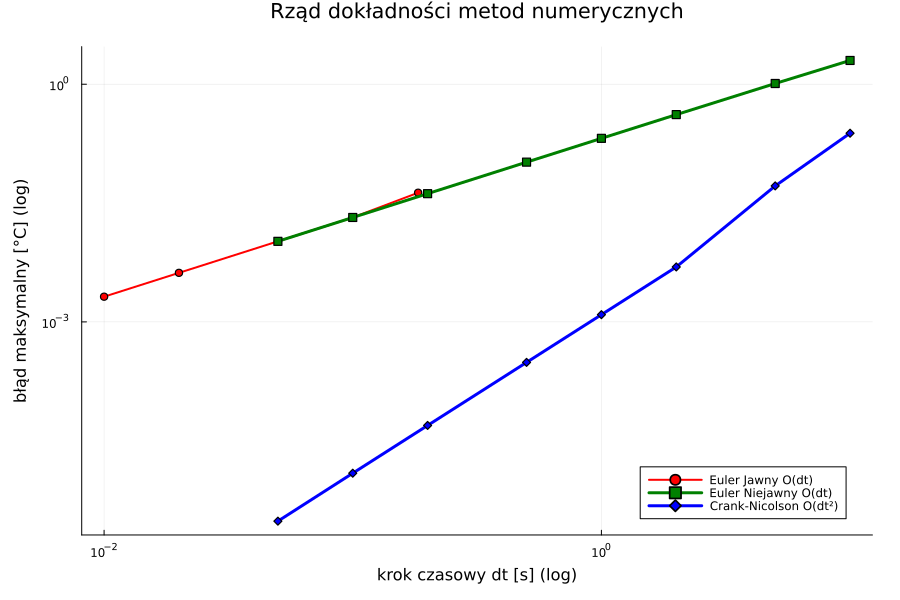

"c:\\Users\\jakub\\Desktop\\porownanie_blad_zbieznosc.png"

In [34]:
t_docelowe = 50.0

dt_ref = 0.005
_, sol_ref = solve_rod_crank_nicolson(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=dt_ref, t_end=t_docelowe)
T_prawdziwe = sol_ref[end, :]

dt_safe = explicit_dt_limit(k_het, rhoc_het, dx; safety=0.95)
dt_test_exp = [0.01, 0.02, 0.05, 0.1, dt_safe] 
dt_test_imp = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]

err_exp = Float64[]
err_imp = Float64[]
err_cn  = Float64[]

for dt in dt_test_exp
    _, sol = solve_rod_explicit(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=dt, t_end=t_docelowe)
    push!(err_exp, maximum(abs.(sol[end, :] .- T_prawdziwe)))
end

for dt in dt_test_imp
    _, sol1 = solve_rod_implicit(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=dt, t_end=t_docelowe)
    push!(err_imp, maximum(abs.(sol1[end, :] .- T_prawdziwe)))
    
    _, sol2 = solve_rod_crank_nicolson(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=dt, t_end=t_docelowe)
    push!(err_cn, maximum(abs.(sol2[end, :] .- T_prawdziwe)))
end

p4 = plot(title="Rząd dokładności metod numerycznych", 
          xlabel="krok czasowy dt [s] (log)", 
          ylabel="błąd maksymalny [°C] (log)",
          xaxis=:log10, yaxis=:log10,
          legend=:bottomright, size=(900, 600))

plot!(p4, dt_test_exp, err_exp, label="Euler Jawny O(dt)", color=:red, marker=:circle, linewidth=2)
plot!(p4, dt_test_imp, err_imp, label="Euler Niejawny O(dt)", color=:green, marker=:square, linewidth=3)
plot!(p4, dt_test_imp, err_cn, label="Crank-Nicolson O(dt²)", color=:blue, marker=:diamond, linewidth=3)

display(p4)
savefig(p4, "porownanie_blad_zbieznosc.png")

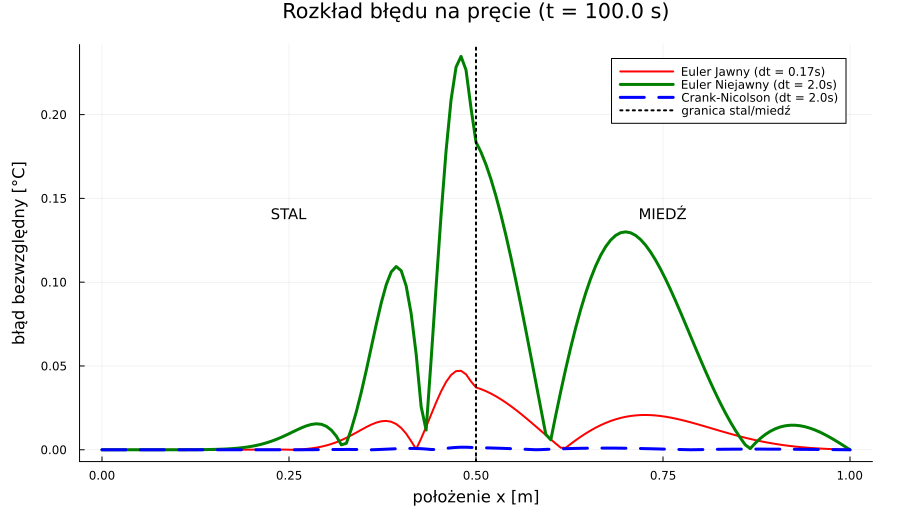

"c:\\Users\\jakub\\Desktop\\porownanie_blad_przestrzenny.png"

In [35]:
#EKSPERYMENT 2: rozkład błędu w przestrzeni
t_cel = 100.0 

dt_ref = 0.01
_, sol_ref = solve_rod_crank_nicolson(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=dt_ref, t_end=t_cel)
T_ref = sol_ref[end, :]

dt_test = 2.0
dt_safe = explicit_dt_limit(k_het, rhoc_het, dx; safety=0.9) # Krok dla jawnego (będzie malutki!)

_, sol_exp = solve_rod_explicit(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=dt_safe, t_end=t_cel)
_, sol_imp = solve_rod_implicit(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=dt_test, t_end=t_cel)
_, sol_cn  = solve_rod_crank_nicolson(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=dt_test, t_end=t_cel)

err_exp = abs.(sol_exp[end, :] .- T_ref)
err_imp = abs.(sol_imp[end, :] .- T_ref)
err_cn  = abs.(sol_cn[end, :] .- T_ref)

p5 = plot(title="Rozkład błędu na pręcie (t = $t_cel s)", 
          xlabel="położenie x [m]", 
          ylabel="błąd bezwzględny [°C]", 
          legend=:topright, size=(900, 520))

plot!(p5, x, err_exp, label="Euler Jawny (dt = $(round(dt_safe, digits=2))s)", color=:red, linewidth=2)
plot!(p5, x, err_imp, label="Euler Niejawny (dt = $(dt_test)s)", color=:green, linewidth=3)
plot!(p5, x, err_cn,  label="Crank-Nicolson (dt = $(dt_test)s)", color=:blue, linewidth=3, linestyle=:dash)

vline!(p5, [0.5], label="granica stal/miedź", color=:black, linestyle=:dot)
annotate!(0.25, maximum(err_imp)*0.6, text("STAL", 10))
annotate!(0.75, maximum(err_imp)*0.6, text("MIEDŹ", 10))

display(p5)
savefig(p5, "porownanie_blad_przestrzenny.png")

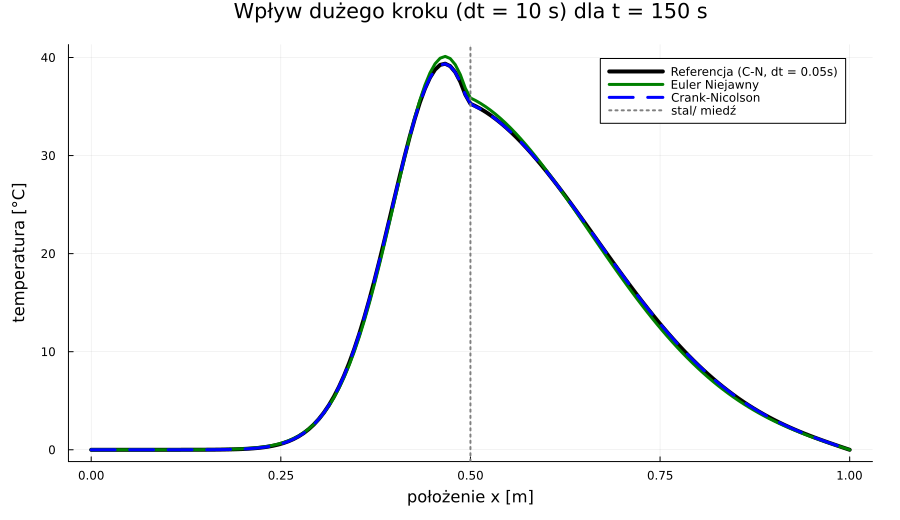

"c:\\Users\\jakub\\Desktop\\porownanie_tlumienie.png"

In [36]:
#EKSPERYMENT 1: dokladnosc przy ogromnym kroku czasowym
x, k_het, rhoc_het, _ = build_rod(rod_heterogeneous; Nx=151)
T0 = 100 .* exp.(-((x .- 0.5).^2) ./ (2 * 0.05^2))

#rozwiazanie referencyjne z bardzo malym krokiem czasowym
dt_ref = 0.05
t_target = 150.0
_, sol_ref = solve_rod_crank_nicolson(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=dt_ref, t_end=t_target)

#duzy krok czasowy
dt_huge = 10.0
_, sol_imp_huge = solve_rod_implicit(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=dt_huge, t_end=t_target)
_, sol_cn_huge  = solve_rod_crank_nicolson(x, k_het, rhoc_het; T_initial=T0, T_left=0.0, T_right=0.0, dt=dt_huge, t_end=t_target)

p2 = plot(title="Wpływ dużego kroku (dt = 10 s) dla t = 150 s", 
          xlabel="położenie x [m]", ylabel="temperatura [°C]", legend=:topright)

plot!(p2, x, sol_ref[end, :], label="Referencja (C-N, dt = 0.05s)", color=:black, linewidth=4)
plot!(p2, x, sol_imp_huge[end, :], label="Euler Niejawny", color=:green, linewidth=3)
plot!(p2, x, sol_cn_huge[end, :], label="Crank-Nicolson", color=:blue, linewidth=3, linestyle=:dash)

vline!(p2, [0.5], label="stal/ miedź", color=:gray, linestyle=:dot)
display(p2)
savefig(p2, "porownanie_tlumienie.png")